# Griffiths Problem 1.13 -- Buffon's needle, and how dropping it measures $\pi$
### $P=\dfrac{2}{\pi}$, verified by SymPy and then *rediscovered* by throwing needles in Torch

Drop a needle of length $l$ onto paper ruled with parallel lines spaced $l$ apart. The chance it
crosses a line is
$$P=\frac{2}{\pi}\approx 0.6366.$$
Griffiths builds it on Problem 1.12: for a needle whose lower end sits a height $y$ above a line, the
conditional crossing probability is
$$P(y)=1-\frac{1}{\pi}\Big[\sin^{-1}\!\tfrac{y}{l}+\sin^{-1}\!\big(1-\tfrac{y}{l}\big)\Big],$$
and averaging over $y$ uniform on $[0,l]$ gives $2/\pi$.

As before we **derive and `assert` it in SymPy**, then run a **Torch** Monte-Carlo that literally
drops millions of needles -- and because $\pi=2/P$, the experiment turns into an estimator of $\pi$
itself. That is Buffon's 1777 needle, the **first Monte-Carlo method**, and the same sampling logic
that validates every notebook in this repo. Runs on the Python 3.12 + Torch kernel.

In [1]:
import sympy as sp
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
sp.init_printing()
y, l = sp.symbols('y l', positive=True)
print("sympy", sp.__version__, "| torch", torch.__version__, "| pandas", pd.__version__)

sympy 1.14.0 | torch 2.11.0+cu128 | pandas 2.3.3


## (a) The conditional crossing probability $P(y)$

From Problem 1.12, the projection of a randomly angled needle gives an arcsine law, and integrating
it over the crossing region yields $P(y)=1-\tfrac1\pi[\sin^{-1}(y/l)+\sin^{-1}(1-y/l)]$. It equals
$\tfrac12$ at the edges ($y=0,l$) and peaks at $\tfrac23$ in the middle ($y=l/2$): a needle centered
between the lines is most likely to reach one.

In [2]:
P_y = 1 - (sp.asin(y/l) + sp.asin(1 - y/l)) / sp.pi

# endpoint and midpoint values
assert sp.simplify(P_y.subs(y, 0) - sp.Rational(1, 2)) == 0        # P(0) = 1/2
assert sp.simplify(P_y.subs(y, l) - sp.Rational(1, 2)) == 0        # P(l) = 1/2
assert sp.simplify(P_y.subs(y, l/2) - sp.Rational(2, 3)) == 0      # P(l/2) = 2/3
print("P(0)   =", sp.simplify(P_y.subs(y, 0)))
print("P(l/2) =", sp.simplify(P_y.subs(y, l/2)))
print("P(l)   =", sp.simplify(P_y.subs(y, l)))

P(0)   = 1/2
P(l/2) = 2/3
P(l)   = 1/2


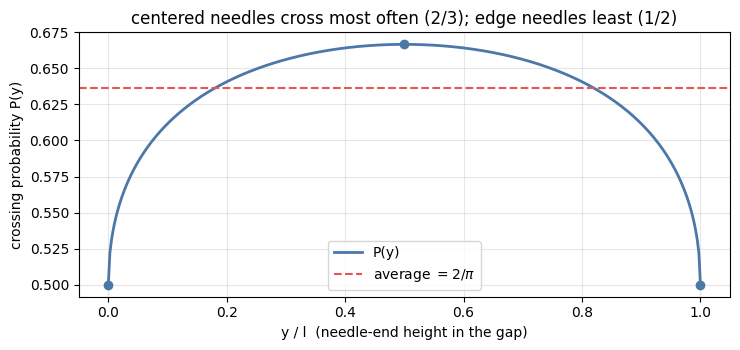

In [3]:
# Graph P(y) over the gap, with the average line at 2/pi
yy = np.linspace(1e-6, 1-1e-6, 400)                 # y/l
Pyn = 1 - (np.arcsin(yy) + np.arcsin(1-yy))/np.pi
plt.figure(figsize=(7.5, 3.6))
plt.plot(yy, Pyn, color="#4C78A8", lw=2, label="P(y)")
plt.axhline(2/np.pi, ls="--", color="#E45756", label=r"average $=2/\pi$")
plt.plot([0,0.5,1], [0.5,2/3,0.5], "o", color="#4C78A8")
plt.xlabel("y / l  (needle-end height in the gap)"); plt.ylabel("crossing probability P(y)")
plt.title("centered needles cross most often (2/3); edge needles least (1/2)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## (b) Average over the gap: $P=\dfrac1l\displaystyle\int_0^l P(y)\,dy=\dfrac{2}{\pi}$

All landing heights are equally likely, so integrate $P(y)$ and divide by $l$. SymPy does the arcsine
integrals; the `assert` is Buffon's answer $2/\pi$.

In [4]:
P = sp.integrate(P_y, (y, 0, l)) / l
P = sp.simplify(P)
assert sp.simplify(P - 2/sp.pi) == 0
print("P =", P, "=", float(P))

# the general short needle (length a <= spacing d) is P = 2a/(pi d); l=d recovers 2/pi
a, d = sp.symbols('a d', positive=True)
theta = sp.symbols('theta', positive=True)
# center-to-nearest-line c uniform on [0, d/2], angle uniform on [0, pi/2], crosses if c <= (a/2) sin(theta)
P_general = sp.integrate(sp.integrate(1, (sp.Symbol('c'), 0, (a/2)*sp.sin(theta))),
                         (theta, 0, sp.pi/2)) / ((d/2) * (sp.pi/2))
assert sp.simplify(P_general - 2*a/(sp.pi*d)) == 0
print("general short needle: P =", sp.simplify(P_general), " -> at a=d:",
      sp.simplify(P_general.subs(a, d)))

P = 2/pi = 0.6366197723675814
general short needle: P = 2*a/(pi*d)  -> at a=d: 2/pi


## Rediscover it by throwing needles (Torch) -- and thereby measure $\pi$

Simulate the drop directly: each needle has a random angle $\theta\sim U(0,\pi)$ and a random
center-to-nearest-line distance $c\sim U(0,l/2)$. It crosses when $c\le\tfrac{l}{2}\sin\theta$. The
crossing fraction estimates $P$, and since $P=2/\pi$, **$\hat\pi=2/\hat P$** -- Monte-Carlo $\pi$
from geometry alone.

crossing fraction P_hat = 0.63646   (exact 2/pi = 0.63662)
pi estimate  2/P_hat    = 3.14240   (true pi = 3.14159)


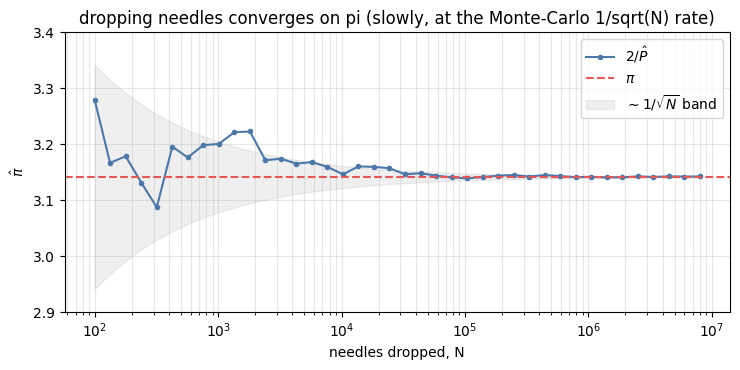

In [5]:
torch.manual_seed(0)
N = 8_000_000
l_len = 1.0
theta = torch.rand(N) * torch.pi
c = torch.rand(N) * (l_len/2)                       # center distance to nearest line
crossed = c <= (l_len/2) * torch.sin(theta)
P_hat = crossed.float().mean()
pi_hat = 2.0 / P_hat
print(f"crossing fraction P_hat = {float(P_hat):.5f}   (exact 2/pi = {2/np.pi:.5f})")
print(f"pi estimate  2/P_hat    = {float(pi_hat):.5f}   (true pi = {np.pi:.5f})")

# convergence of the pi estimate as more needles fall
Ns = np.unique(np.logspace(2, np.log10(N), 40).astype(int))
cum = torch.cumsum(crossed.float(), 0)
pi_run = np.array([2.0 / (float(cum[n-1]) / n) for n in Ns])
plt.figure(figsize=(7.5, 3.8))
plt.semilogx(Ns, pi_run, "o-", ms=3, color="#4C78A8", label=r"$2/\hat P$")
plt.axhline(np.pi, ls="--", color="#E45756", label=r"$\pi$")
plt.fill_between(Ns, np.pi - 2/np.sqrt(Ns), np.pi + 2/np.sqrt(Ns), alpha=0.12, color="gray",
                 label=r"$\sim 1/\sqrt{N}$ band")
plt.xlabel("needles dropped, N"); plt.ylabel(r"$\hat\pi$"); plt.ylim(2.9, 3.4)
plt.title("dropping needles converges on pi (slowly, at the Monte-Carlo 1/sqrt(N) rate)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## Summary table (Pandas)

In [6]:
rows = [
    {"quantity": "P (cross)", "exact": round(2/np.pi, 5), "torch MC": round(float(P_hat), 5),
     "abs error": f"{abs(float(P_hat)-2/np.pi):.2e}", "match": abs(float(P_hat)-2/np.pi) < 3e-3},
    {"quantity": "pi = 2/P",  "exact": round(np.pi, 5),   "torch MC": round(float(pi_hat), 5),
     "abs error": f"{abs(float(pi_hat)-np.pi):.2e}", "match": abs(float(pi_hat)-np.pi) < 1e-2},
]
df = pd.DataFrame(rows)
print(df.to_string(index=False))
assert df["match"].all()
print("\nBuffon's needle P = 2/pi confirmed, and 2/P recovers pi.")

 quantity   exact  torch MC abs error  match
P (cross) 0.63662   0.63646  1.65e-04   True
 pi = 2/P 3.14159   3.14240  8.12e-04   True

Buffon's needle P = 2/pi confirmed, and 2/P recovers pi.


## Application: the first Monte-Carlo method

Buffon's needle (1777) is where **Monte-Carlo** was born: estimate a number you can't easily
integrate by sampling a random physical process and counting. The needle turns the *geometric*
constant $\pi$ into a *statistical* one -- exactly the move behind:

* **Monte-Carlo integration** -- averaging random samples to evaluate hard integrals (the $1/\sqrt N$
  error we just watched);
* the **sampling checks** that validate the SymPy results in these notebooks;
* stochastic estimators throughout the repo -- the effective-resistance commute-time walk
  (`dgs.effective_resistance`), the random-forest bootstrap (`dgs.decision_tree`), and any
  randomized phase-retrieval initialization.

One dropped needle is one bit of evidence about $\pi$; average enough of them and geometry falls out
of chance.

## What we did

* Wrote the conditional $P(y)=1-\tfrac1\pi[\sin^{-1}(y/l)+\sin^{-1}(1-y/l)]$, checked its
  $\tfrac12,\tfrac23,\tfrac12$ values in SymPy.
* Averaged it exactly to Buffon's $P=2/\pi$, and verified the general short-needle law
  $P=2a/(\pi d)$.
* **Dropped 8 million needles in Torch**, recovered $P\approx2/\pi$ and $\hat\pi=2/\hat P\approx\pi$
  with $1/\sqrt N$ convergence, tabled in Pandas.
* Placed it as the origin of **Monte-Carlo** -- geometry measured by chance.

Completes the 1.11 -> 1.12 -> 1.13 arc: uniform angle -> its projection (arcsine) -> a needle
crossing lines -> $\pi$ from randomness.